In [3]:
# Imports
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [4]:
# Load data
df = pd.read_csv("../data/processed/telco_customer_churn_clean.csv")

In [5]:
df["Churn"] = df["Churn Label"].map({
    "No": 0,
    "Yes": 1
})

In [6]:
X = df.drop(
    columns=[
        "City",
        "Zip Code",
        "Lat Long",
        "Latitude",
        "Longitude",
        "CLTV",
        "Churn Label",
        "Churn"
    ]
)

y = df["Churn"]

In [7]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [9]:

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [10]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


In [11]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, max_iter=1000)

lr.fit(X_train_processed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [12]:
y_pred_lr = lr.predict(X_test_processed)
y_prob_lr = lr.predict_proba(X_test_processed)[:, 1]

In [13]:
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
roc_auc = roc_auc_score(y_test, y_prob_lr)

In [14]:
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

Accuracy : 0.8020
Precision: 0.6435
Recall   : 0.5695
F1 Score : 0.6043
ROC AUC  : 0.8489


In [15]:
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)

[[917 118]
 [161 213]]


In [16]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [17]:
results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1],
    "ROC AUC": [roc_auc]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.801987,0.643505,0.569519,0.604255,0.848867


## Logistic Regression Results

Logistic Regression was used as the baseline machine learning model for customer churn prediction.

### Performance Metrics

- Accuracy: 80.20%
- Precision: 64.35%
- Recall: 56.95%
- F1 Score: 60.43%
- ROC-AUC Score: 84.89%

### Interpretation

The model achieved good overall performance with an ROC-AUC score of 84.89%, indicating a strong ability to distinguish between customers who are likely to churn and those who are not.

Although the overall accuracy is satisfactory, the recall suggests that some churning customers are still being missed. More advanced models such as Decision Tree and Random Forest will be evaluated to determine whether they improve churn detection.

# Decision Tree Model

In [18]:
dt = DecisionTreeClassifier(random_state=42)

In [19]:
dt.fit(X_train_processed, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [20]:
y_pred_dt = dt.predict(X_test_processed)
y_prob_dt = dt.predict_proba(X_test_processed)[:, 1]

In [21]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

In [22]:
print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1 Score :", f1_dt)
print("ROC AUC  :", roc_auc_dt)

Accuracy : 0.7423704755145494
Precision: 0.5137844611528822
Recall   : 0.5481283422459893
F1 Score : 0.5304010349288486
ROC AUC  : 0.680126068872872


In [23]:
print(confusion_matrix(y_test, y_pred_dt))

[[841 194]
 [169 205]]


In [24]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.83      0.81      0.82      1035
           1       0.51      0.55      0.53       374

    accuracy                           0.74      1409
   macro avg       0.67      0.68      0.68      1409
weighted avg       0.75      0.74      0.74      1409



In [25]:
results.loc[len(results)] = [
    "Decision Tree",
    accuracy_dt,
    precision_dt,
    recall_dt,
    f1_dt,
    roc_auc_dt
]

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.801987,0.643505,0.569519,0.604255,0.848867
1,Decision Tree,0.742370,0.513784,0.548128,0.530401,0.680126


# RANDOM FOREST


In [26]:
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

In [27]:
rf.fit(X_train_processed, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
y_pred_rf = rf.predict(X_test_processed)
y_prob_rf = rf.predict_proba(X_test_processed)[:, 1]

In [29]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

In [30]:
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)
print("ROC AUC  :", roc_auc_rf)

Accuracy : 0.7849538679914834
Precision: 0.6203389830508474
Recall   : 0.4893048128342246
F1 Score : 0.547085201793722
ROC AUC  : 0.8324420677361855


In [31]:
print(confusion_matrix(y_test, y_pred_rf))

[[923 112]
 [191 183]]


In [32]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



In [33]:
results.loc[len(results)] = [
    "Random Forest",
    accuracy_rf,
    precision_rf,
    recall_rf,
    f1_rf,
    roc_auc_rf
]

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.801987,0.643505,0.569519,0.604255,0.848867
1,Decision Tree,0.742370,0.513784,0.548128,0.530401,0.680126
2,Random Forest,0.784954,0.620339,0.489305,0.547085,0.832442


## Model Comparison

Three machine learning algorithms were evaluated:

- Logistic Regression
- Decision Tree
- Random Forest

Among these, Logistic Regression achieved the best overall performance.

### Best Model: Logistic Regression

Performance:
- Accuracy: 80.20%
- Precision: 64.35%
- Recall: 56.95%
- F1 Score: 60.43%
- ROC-AUC: 84.89%

### Conclusion

Logistic Regression was selected as the final model because it achieved the best balance across all evaluation metrics and demonstrated the strongest ability to distinguish customers who are likely to churn from those who are not.

# Hyperparameter Tuning

In [34]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [35]:
dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [36]:
grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_dt.fit(X_train_processed, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [37]:
print(grid_dt.best_params_)
print(grid_dt.best_score_)

{'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
0.8397709954483016


In [38]:
best_dt = grid_dt.best_estimator_

y_pred = best_dt.predict(X_test_processed)
y_prob = best_dt.predict_proba(X_test_processed)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.794180269694819
Precision: 0.6160220994475138
Recall: 0.5962566844919787
F1: 0.6059782608695652
ROC AUC: 0.8357048748353096


In [39]:
rf = RandomForestClassifier(random_state=42)

In [40]:
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [41]:
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

In [42]:
grid_rf.fit(X_train_processed, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [43]:
print("Best Parameters:", grid_rf.best_params_)
print("Best CV ROC-AUC:", grid_rf.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV ROC-AUC: 0.8601717730238153


In [44]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test_processed)
y_prob_rf = best_rf.predict_proba(X_test_processed)[:, 1]

In [45]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)
print("ROC AUC  :", roc_auc_rf)

Accuracy : 0.8034066713981547
Precision: 0.6510903426791277
Recall   : 0.5588235294117647
F1 Score : 0.6014388489208633
ROC AUC  : 0.8523004985920586


## Hyperparameter Tuning Results

Hyperparameter tuning was performed using GridSearchCV on both Decision Tree and Random Forest models.

### Decision Tree

Best Parameters:
- max_depth = 5
- min_samples_leaf = 4
- min_samples_split = 2

Performance:
- Accuracy: 79.42%
- ROC-AUC: 83.57%

### Random Forest

Best Parameters:
- n_estimators = 200
- max_depth = 10
- min_samples_leaf = 2
- min_samples_split = 5

Performance:
- Accuracy: 80.34%
- ROC-AUC: 85.23%

### Conclusion

Hyperparameter tuning improved the performance of both tree-based models. The Tuned Random Forest achieved the best overall performance and was selected as the final model for this project.

# Feature Importance

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

In [47]:
feature_names = preprocessor.get_feature_names_out()

In [48]:
importance = best_rf.feature_importances_

In [49]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

In [50]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
0,num__Tenure Months,0.125905
2,num__Total Charges,0.109068
37,cat__Contract_Month-to-month,0.098702
1,num__Monthly Charges,0.074733
19,cat__Online Security_No,0.052565
17,cat__Internet Service_Fiber optic,0.043973
28,cat__Tech Support_No,0.043205
10,cat__Dependents_Yes,0.041147
44,cat__Payment Method_Electronic check,0.039737
39,cat__Contract_Two year,0.035391


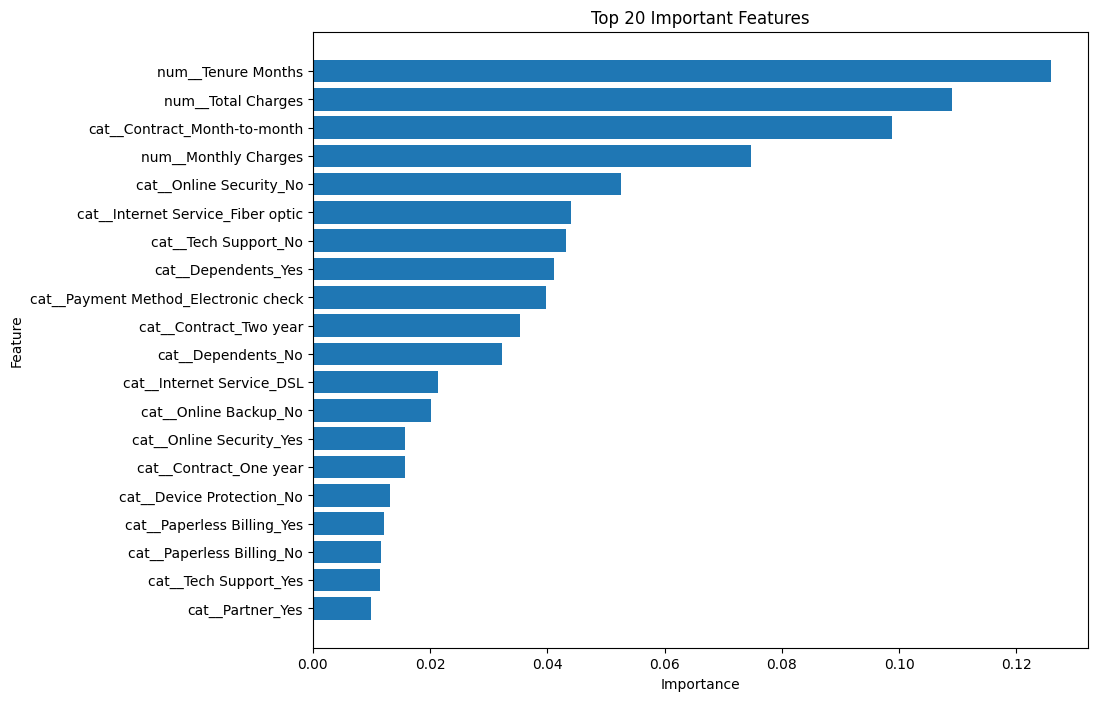

In [51]:
top20 = feature_importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(top20["Feature"], top20["Importance"])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [52]:
feature_importance.to_csv(
    "../reports/feature_importance.csv",
    index=False
)

# Feature Importance

Feature importance analysis was performed using the tuned Random Forest model.

## Top Features

1. Tenure Months
2. Total Charges
3. Month-to-month Contract
4. Monthly Charges
5. Online Security
6. Fiber Optic Internet
7. Tech Support
8. Dependents
9. Electronic Check
10. Two-Year Contract

## Business Insights

- Customers with longer tenure are less likely to churn.
- Month-to-month contracts have a higher risk of churn.
- Customers with higher monthly charges are more likely to leave.
- Online Security and Tech Support improve customer retention.
- Long-term contracts contribute to customer loyalty.

# DEPLOYMENT


In [53]:
import joblib

In [54]:
joblib.dump(best_rf, "../models/random_forest_model.pkl")

['../models/random_forest_model.pkl']

In [55]:
joblib.dump(preprocessor, "../models/preprocessor.pkl")

['../models/preprocessor.pkl']

In [57]:
loaded_model = joblib.load("../models/random_forest_model.pkl")
loaded_preprocessor = joblib.load("../models/preprocessor.pkl")

print(type(loaded_model))
print(type(loaded_preprocessor))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
<class 'sklearn.compose._column_transformer.ColumnTransformer'>
